# Model Training including LSTM

## 1. Data Collection — Hopsworks Feature Store

In [1]:
import hopsworks
import numpy as np
import pandas as pd

# Connect to Hopsworks Feature Store
project = hopsworks.login()
fs = project.get_feature_store(name="aqi_predictor_fsd_featurestore")
fg = fs.get_feature_group("weather_aqi_hourly", version=6)

# Read dataset via Online Store
df = fg.read(online=True)

# Sort chronologically (Online store returns unsorted records)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

target_cols = ["target_aqi_24h", "target_aqi_48h", "target_aqi_72h"]

print(f"Total rows: {len(df)}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")
print(f"Columns: {df.shape[1]}")


2026-08-29 23:30:16,130 INFO: Initializing external client
2026-08-29 23:30:16,131 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-29 23:30:19,777 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42119
Total rows: 17664
Date range: 2024-08-24 00:00:00 to 2026-08-29 23:00:00
Columns: 45


In [2]:
# Freeze a snapshot for this experiment run so results are reproducible
# (the online store keeps growing every hour — without freezing, train/test
#  cutoffs silently shift between notebook runs, making results incomparable)
SNAPSHOT_PATH = "aqi_snapshot.parquet"
df.to_parquet(SNAPSHOT_PATH)
print(f"Snapshot saved: {SNAPSHOT_PATH} ({len(df)} rows, through {df['time'].max()})")


Snapshot saved: aqi_snapshot.parquet (17664 rows, through 2026-08-29 23:00:00)


## 2. Data Cleaning

Load from the frozen snapshot from here on, so re-running this notebook doesn't
silently change the dataset underneath you.

In [3]:
import pandas as pd
import numpy as np 

df = pd.read_parquet('aqi_snapshot.parquet')

print("=== Shape ===")
print(df.shape)

print("\n=== Dtypes ===")
print(df.dtypes)

print("\n=== Missing values per column ===")
missing = df.isna().sum()
print(missing[missing > 0])

print("\n=== Duplicate rows ===")
print(df.duplicated().sum())


=== Shape ===
(17664, 45)

=== Dtypes ===
time                    datetime64[ns]
temperature_2m                 float64
relative_humidity_2m             int64
surface_pressure               float64
wind_speed_10m                 float64
wind_direction_10m               int64
pm2_5                          float64
pm10                           float64
nitrogen_dioxide               float64
ozone                          float64
us_aqi                           int64
city                            object
wind_u                         float64
wind_v                         float64
hour                             int64
dayofweek                        int64
month                            int64
dayofyear                        int64
is_weekend                       int64
is_burning_season                int64
sin_hour                       float64
cos_hour                       float64
sin_month                      float64
cos_month                      float64
pm2_5_lag_1h          

In [5]:
# Targets are NaN for the most recent rows by construction (24h/48h/72h ahead
# doesn't exist yet for the last few hours of data) — that's expected, not a data
# quality problem. Drop those rows for training; keep the raw df for inference use.
before = len(df)
target_cols = ["target_aqi_24h", "target_aqi_48h", "target_aqi_72h"]
df = df.dropna(subset=target_cols).reset_index(drop=True)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Dropped {before - after} rows (missing targets / duplicates). Remaining: {after}")


Dropped 72 rows (missing targets / duplicates). Remaining: 17592


## 3. Exploratory Data Analysis

In [6]:
numeric_df = df.select_dtypes(include=['number'])
numeric_metrics = numeric_df.agg(['min', 'max', 'std', 'mean', 'median']).T
print(numeric_metrics)


                             min          max         std          mean  \
temperature_2m          2.400000    46.900000    8.533641  2.539485e+01   
relative_humidity_2m    4.000000   100.000000   22.383692  5.856548e+01   
surface_pressure      969.400000  1005.500000    7.027610  9.863164e+02   
wind_speed_10m          0.000000    38.400000    3.376699  6.439853e+00   
wind_direction_10m      1.000000   360.000000   97.453504  1.630279e+02   
pm2_5                   3.400000   486.200000   66.726711  8.286771e+01   
pm10                    3.400000   804.700000   80.572785  1.106503e+02   
nitrogen_dioxide        0.000000   187.000000   33.031952  3.749816e+01   
ozone                   0.000000   257.000000   61.590694  8.504593e+01   
us_aqi                 69.000000   437.000000   54.714755  1.663313e+02   
wind_u                -31.066253    20.353490    5.212757 -1.647225e+00   
wind_v                -26.588439    21.825889    4.777071  4.115912e-01   
hour                    0

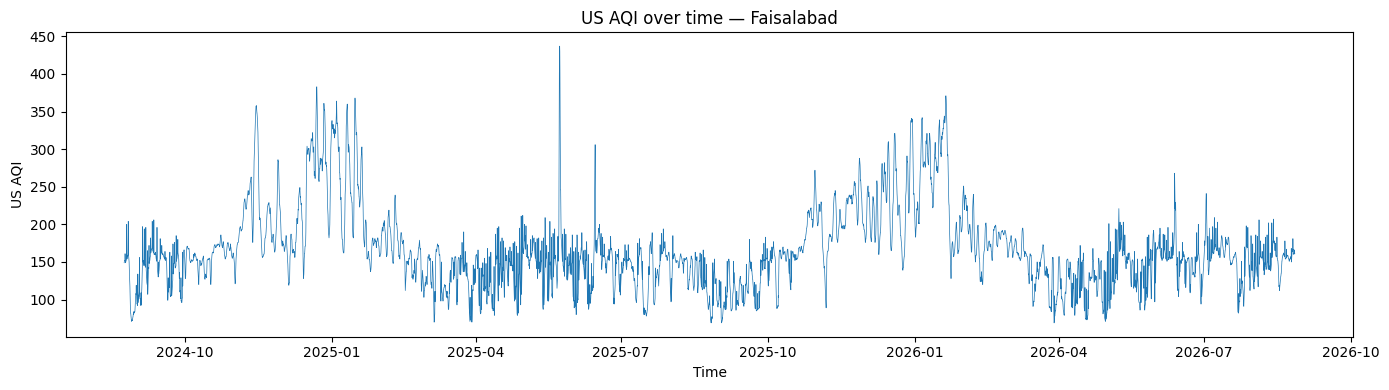

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['time'], df['us_aqi'], linewidth=0.5)
ax.set_title("US AQI over time — Faisalabad")
ax.set_xlabel("Time")
ax.set_ylabel("US AQI")
plt.tight_layout()
plt.savefig("aqi_over_time.png", dpi=150)
plt.show()


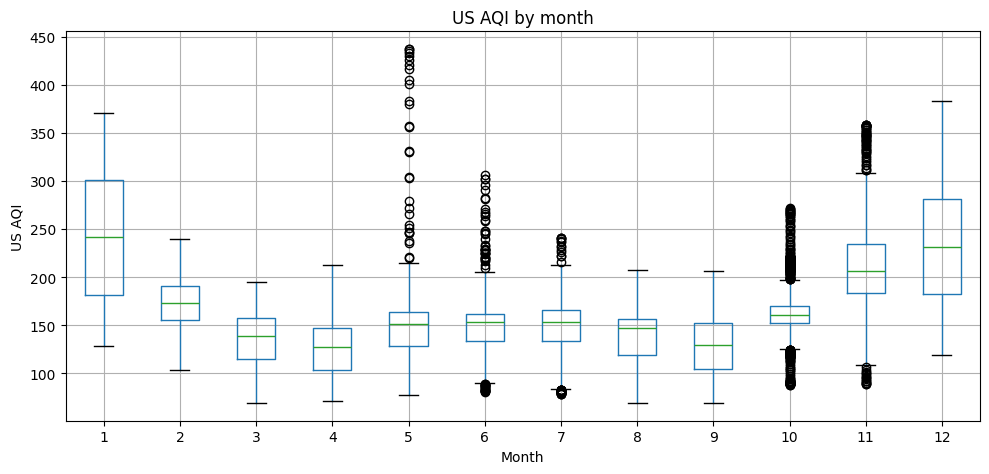

In [8]:
# Distribution of the target vs season — this is the check that matters most
# for this dataset: AQI is strongly seasonal (burning season vs monsoon), and
# that seasonality is exactly what drives the train/test regime mismatch seen
# in earlier experiments.
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column='us_aqi', by='month', ax=ax)
ax.set_title("US AQI by month")
ax.set_xlabel("Month")
ax.set_ylabel("US AQI")
plt.suptitle("")
plt.tight_layout()
plt.savefig("aqi_by_month.png", dpi=150)
plt.show()


## 4. Time-Aware Train / Validation / Test Split

A `GAP` of 72 rows is inserted after each split boundary. Since the furthest
target looks 72 hours ahead, this prevents a training row's target from
peeking into the validation/test period (leakage).

In [9]:
target_cols = ["target_aqi_24h", "target_aqi_48h", "target_aqi_72h"]
metadata_cols = ["time", "city"]
feature_cols = [c for c in df.columns if c not in target_cols + metadata_cols]

X = df[feature_cols]
y = df[target_cols]

n = len(df)
train_end = int(n * 0.80)
val_end = int(n * 0.90)
GAP = 72

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end + GAP:val_end], y.iloc[train_end + GAP:val_end]
X_test, y_test = X.iloc[val_end + GAP:], y.iloc[val_end + GAP:]

print(f"Train: {df['time'].iloc[0]} -> {df['time'].iloc[train_end-1]}  ({len(X_train)} rows)")
print(f"Val:   {df['time'].iloc[train_end+GAP]} -> {df['time'].iloc[val_end-1]}  ({len(X_val)} rows)")
print(f"Test:  {df['time'].iloc[val_end+GAP]} -> {df['time'].iloc[-1]}  ({len(X_test)} rows)")

# Regime check — flag any large train/test distribution shift up front,
# rather than discovering it after several rounds of model debugging
for col in ['us_aqi']:
    tr, te = X_train[col], X_test[col]
    print(f"\n{col} — Train: mean={tr.mean():.1f} std={tr.std():.1f} | "
          f"Test: mean={te.mean():.1f} std={te.std():.1f}")
    if abs(tr.std() - te.std()) / tr.std() > 0.3:
        print("  ⚠ Test variance differs from train by >30% — expect R² to behave "
              "erratically on this split; prioritize MAE/RMSE and time-series CV "
              "over a single-split R².")


Train: 2024-08-24 00:00:00 -> 2026-04-02 08:00:00  (14073 rows)
Val:   2026-04-05 09:00:00 -> 2026-06-14 15:00:00  (1687 rows)
Test:  2026-06-17 16:00:00 -> 2026-08-26 23:00:00  (1688 rows)

us_aqi — Train: mean=172.0 std=58.1 | Test: mean=151.8 std=23.0
  ⚠ Test variance differs from train by >30% — expect R² to behave erratically on this split; prioritize MAE/RMSE and time-series CV over a single-split R².


## 5. Feature Selection (Spearman correlation, computed on TRAIN ONLY)

In [10]:
train_df = df.iloc[:train_end].copy()
numeric_train_df = train_df.select_dtypes(include=[np.number])
corr_matrix = numeric_train_df.corr(method="spearman")

top_features_per_target = {}
for target in target_cols:
    top = (corr_matrix[target]
           .drop(labels=target_cols, errors="ignore")
           .abs()
           .sort_values(ascending=False)
           .head(15))
    top_features_per_target[target] = top
    print(f"\nTop features for {target}:")
    print(top)



Top features for target_aqi_24h:
us_aqi                  0.822030
us_aqi_lag_1h           0.811123
pm2_5_roll_mean_24h     0.805112
us_aqi_roll_mean_24h    0.754831
us_aqi_roll_min_24h     0.749465
us_aqi_roll_max_24h     0.725243
pm2_5_roll_mean_6h      0.717139
us_aqi_lag_24h          0.713927
pm2_5                   0.712482
pm2_5_roll_std_24h      0.700501
pm2_5_lag_1h            0.692631
us_aqi_lag_48h          0.675009
cos_month               0.666451
us_aqi_lag_72h          0.658297
surface_pressure        0.613615
Name: target_aqi_24h, dtype: float64

Top features for target_aqi_48h:
us_aqi                  0.714113
us_aqi_lag_1h           0.708401
pm2_5_roll_mean_24h     0.703071
us_aqi_roll_mean_24h    0.687368
us_aqi_roll_min_24h     0.678531
us_aqi_lag_24h          0.675493
cos_month               0.669705
us_aqi_lag_48h          0.660692
us_aqi_roll_max_24h     0.655338
us_aqi_lag_72h          0.646114
pm2_5_roll_std_24h      0.631162
surface_pressure        0.612762
pm2_

In [11]:
FINAL_FEATURES = [
    # Current / near-term AQI state
    "us_aqi", "us_aqi_lag_1h", "pm25_pm10_ratio",
    # PM2.5 / PM10 pollutant signal
    "pm2_5", "pm2_5_lag_1h", "pm2_5_roll_mean_6h", "pm2_5_roll_mean_24h",
    "pm2_5_roll_std_24h", "pm10",
    # Diurnal lags
    "us_aqi_lag_24h", "us_aqi_lag_48h", "us_aqi_lag_72h",
    # Rolling context
    "us_aqi_roll_mean_24h", "us_aqi_roll_min_24h", "us_aqi_roll_max_24h", "us_aqi_roll_std_24h",
    # Meteorology
    "temperature_2m", "relative_humidity_2m", "surface_pressure",
    "wind_speed_10m", "wind_u", "wind_v",
    # Seasonal / regional
    "is_burning_season",
    # Cyclical time encodings
    "cos_month", "sin_month", "cos_hour", "sin_hour", "is_weekend",
]

x_train_filtered = X_train[FINAL_FEATURES]
x_val_filtered = X_val[FINAL_FEATURES]
x_test_filtered = X_test[FINAL_FEATURES]

y_train_24h, y_val_24h, y_test_24h = y_train["target_aqi_24h"], y_val["target_aqi_24h"], y_test["target_aqi_24h"]
y_train_48h, y_val_48h, y_test_48h = y_train["target_aqi_48h"], y_val["target_aqi_48h"], y_test["target_aqi_48h"]
y_train_72h, y_val_72h, y_test_72h = y_train["target_aqi_72h"], y_val["target_aqi_72h"], y_test["target_aqi_72h"]

print(f"Using {len(FINAL_FEATURES)} features")


Using 28 features


## 6. Baseline Model — Persistence

The simplest possible forecast: "AQI N hours from now = AQI right now."
For autocorrelated series like AQI, this is a genuinely strong baseline — any
real model needs to beat it, not just beat zero.

In [12]:
from sklearn.metrics import (mean_squared_error, root_mean_squared_error,
                              mean_absolute_error, mean_absolute_percentage_error, r2_score)

def evaluate(y_true, y_pred, label):
    return {
        "Model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

baseline_24h = evaluate(y_test_24h, x_test_filtered['us_aqi'], "Baseline (Persistence)")
print(baseline_24h)


{'Model': 'Baseline (Persistence)', 'MAE': 17.308649289099527, 'RMSE': 23.46305202710296, 'MAPE': 0.12191594024645809, 'R2': -0.04620641170953421}


## 7. Model Training & Comparison — 24h Horizon (primary focus)

Training several model families so results are comparable side by side:
Linear Regression, Ridge, a depth-constrained Decision Tree, Random Forest,
and XGBoost.

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

results_24h = [baseline_24h]

# --- Scaling (only needed for linear-family models; trees are scale-invariant) ---
scaler = RobustScaler()
x_train_scaled = scaler.fit_transform(x_train_filtered)
x_test_scaled = scaler.transform(x_test_filtered)

# --- Linear Regression ---
lin_model = LinearRegression()
lin_model.fit(x_train_scaled, y_train_24h)
results_24h.append(evaluate(y_test_24h, lin_model.predict(x_test_scaled), "Linear Regression"))

# --- Ridge (regularized linear) ---
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(x_train_scaled, y_train_24h)
results_24h.append(evaluate(y_test_24h, ridge_model.predict(x_test_scaled), "Ridge Regression"))

# --- Decision Tree (depth-constrained to avoid overfitting) ---
tree_model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=42)
tree_model.fit(x_train_filtered, y_train_24h)
results_24h.append(evaluate(y_test_24h, tree_model.predict(x_test_filtered), "Decision Tree"))

# --- Random Forest ---
rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=8, min_samples_leaf=10,
    random_state=42, n_jobs=-1,
)
rf_model.fit(x_train_filtered, y_train_24h)
results_24h.append(evaluate(y_test_24h, rf_model.predict(x_test_filtered), "Random Forest"))

# --- XGBoost ---
# xgb_model = XGBRegressor(
#     n_estimators=500, max_depth=4, learning_rate=0.05,
#     subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
#     reg_alpha=0.1, reg_lambda=1.0, random_state=42,
#     early_stopping_rounds=30, eval_metric="mae",
# )

xgb_model = XGBRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    tree_method="hist",     # required for GPU acceleration in current XGBoost
    device="cuda",          # tells XGBoost to run on GPU
)
# xgb_model.fit(x_train_filtered, y_train_24h)
# print("Test MAE (GPU XGBoost):", mean_absolute_error(y_test_24h, xgb_model_gpu.predict(x_test_filtered)))

xgb_model.fit(x_train_filtered, y_train_24h, eval_set=[(x_test_filtered, y_test_24h)], verbose=False)
results_24h.append(evaluate(y_test_24h, xgb_model.predict(x_test_filtered), "XGBoost"))

results_df_24h = pd.DataFrame(results_24h).sort_values("MAE").reset_index(drop=True)
print(results_df_24h.to_string(index=False))


                 Model       MAE      RMSE     MAPE        R2
               XGBoost 13.687646 19.023880 0.097674  0.312225
         Random Forest 14.922724 19.649757 0.100524  0.266225
     Linear Regression 15.581801 19.808815 0.103237  0.254298
      Ridge Regression 15.582078 19.809178 0.103236  0.254271
         Decision Tree 16.951443 22.506845 0.115033  0.037330
Baseline (Persistence) 17.308649 23.463052 0.121916 -0.046206


In [13]:
# Beats-baseline check — the number that actually matters for "is this usable"
baseline_mae = results_df_24h.loc[results_df_24h['Model'] == 'Baseline (Persistence)', 'MAE'].values[0]
results_df_24h['Beats Baseline (MAE)'] = results_df_24h['MAE'] < baseline_mae
print(results_df_24h[['Model', 'MAE', 'R2', 'Beats Baseline (MAE)']].to_string(index=False))


                 Model       MAE        R2  Beats Baseline (MAE)
               XGBoost 13.687646  0.312225                  True
         Random Forest 14.922724  0.266225                  True
     Linear Regression 15.581801  0.254298                  True
      Ridge Regression 15.582078  0.254271                  True
         Decision Tree 16.951443  0.037330                  True
Baseline (Persistence) 17.308649 -0.046206                 False


## 8. Tune the Best Model + Time-Series Cross-Validation

A single train/test split can be misleading (as seen in earlier experiments —
R² swings heavily with test-window variance). Time-series CV averages
performance across multiple rolling windows for a more trustworthy estimate.

In [14]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=5, gap=72),
    random_state=42,
    n_jobs=-1,
)
search.fit(x_train_filtered, y_train_24h)

print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)

best_model_24h = search.best_estimator_
final_test_pred = best_model_24h.predict(x_test_filtered)
print("\nFinal Test MAE:", mean_absolute_error(y_test_24h, final_test_pred))
print("Final Test R2:", r2_score(y_test_24h, final_test_pred))


Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV MAE: 22.68198155189628

Final Test MAE: 14.407256302675364
Final Test R2: 0.3349102304000998


In [15]:
# Per-fold breakdown — trust this over the single test-split R2 above
tscv = TimeSeriesSplit(n_splits=5, gap=72)
fold_scores = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(x_train_filtered)):
    X_tr, X_te = x_train_filtered.iloc[tr_idx], x_train_filtered.iloc[te_idx]
    y_tr, y_te = y_train_24h.iloc[tr_idx], y_train_24h.iloc[te_idx]
    m = XGBRegressor(**{k: v for k, v in search.best_params_.items()}, random_state=42)
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)
    fold_scores.append({
        "fold": fold, "R2": r2_score(y_te, pred),
        "MAE": mean_absolute_error(y_te, pred), "test_std": y_te.std(),
    })

fold_df = pd.DataFrame(fold_scores)
print(fold_df.to_string(index=False))
print(f"\nMean R2: {fold_df['R2'].mean():.3f}   Mean MAE: {fold_df['MAE'].mean():.2f}")


 fold       R2       MAE  test_std
    0 0.608619 30.095761 67.582517
    1 0.198900 20.852385 36.075660
    2 0.387438 18.276558 30.421801
    3 0.640539 22.410833 47.928334
    4 0.804643 21.648247 64.900552

Mean R2: 0.528   Mean MAE: 22.66


In [16]:
importance = pd.Series(best_model_24h.feature_importances_, index=x_train_filtered.columns).sort_values(ascending=False)
print(importance)


pm2_5_roll_mean_24h     0.337087
us_aqi_lag_1h           0.163550
us_aqi                  0.127520
cos_month               0.117791
us_aqi_roll_max_24h     0.039191
pm2_5                   0.025455
pm2_5_roll_mean_6h      0.017872
pm10                    0.015886
pm2_5_lag_1h            0.014644
us_aqi_lag_48h          0.013607
pm25_pm10_ratio         0.011771
wind_speed_10m          0.011381
is_burning_season       0.011242
sin_month               0.009139
wind_v                  0.008743
us_aqi_lag_72h          0.007923
surface_pressure        0.007865
us_aqi_roll_std_24h     0.006990
cos_hour                0.006850
us_aqi_roll_min_24h     0.006584
wind_u                  0.006541
sin_hour                0.006067
us_aqi_lag_24h          0.006058
temperature_2m          0.004614
relative_humidity_2m    0.004550
pm2_5_roll_std_24h      0.003857
us_aqi_roll_mean_24h    0.003746
is_weekend              0.003477
dtype: float32


## 9. 48h and 72h Horizons — Quick Comparison

Using the same feature set and the tuned XGBoost config as a starting point.
Expect MAE to rise and R² to fall as the horizon extends — that degradation is
normal and expected for multi-horizon forecasting, not a bug.

In [17]:
def train_and_eval_horizon(y_train_h, y_test_h, label, params):
    baseline = evaluate(y_test_h, x_test_filtered['us_aqi'], f"Baseline ({label})")
    m = XGBRegressor(**params, random_state=42)
    m.fit(x_train_filtered, y_train_h)
    model_result = evaluate(y_test_h, m.predict(x_test_filtered), f"XGBoost ({label})")
    return [baseline, model_result], m

xgb_params = search.best_params_

results_48h, xgb_model_48h = train_and_eval_horizon(y_train_48h, y_test_48h, "48h", xgb_params)
results_72h, xgb_model_72h = train_and_eval_horizon(y_train_72h, y_test_72h, "72h", xgb_params)

all_horizon_results = pd.DataFrame(
    [results_df_24h.iloc[results_df_24h['MAE'].idxmin()][['Model','MAE','RMSE','MAPE','R2']].to_dict()] +
    [{**r, } for r in results_48h] + [{**r} for r in results_72h]
)
print(pd.DataFrame(results_48h + results_72h).to_string(index=False))


         Model       MAE      RMSE     MAPE        R2
Baseline (48h) 21.782583 29.309904 0.151676 -0.655766
 XGBoost (48h) 19.591533 24.142465 0.131451 -0.123397
Baseline (72h) 21.827014 30.187801 0.150632 -0.755932
 XGBoost (72h) 20.192642 24.876655 0.135321 -0.192419


## 10. Does Accuracy Decay With Distance From Train Cutoff?

Direct empirical test of the "closer to train cutoff = more accurate" question.
Buckets the test set into weekly chunks by how far each row sits from the
training cutoff, and computes MAE per bucket. If the hypothesis holds, MAE
should trend upward (worse) as weeks-since-cutoff increases — though expect it
to be noisy/non-monotonic where seasonal regime, not just distance, dominates.

 weeks_since_cutoff       MAE  n_rows  true_std
                 10 12.089951    16.0 14.764682
                 11 13.462551   168.0 14.061090
                 12 23.676977   168.0 35.655152
                 13 13.660954   168.0 16.080937
                 14 12.177131   168.0  9.627115
                 15 10.178017   168.0 25.716091
                 16 19.438075   168.0 26.253599
                 17 14.106072   168.0 18.657531
                 18 15.807152   168.0 18.333817
                 19 11.337963   168.0 16.216298
                 20 10.250423   160.0  4.930715


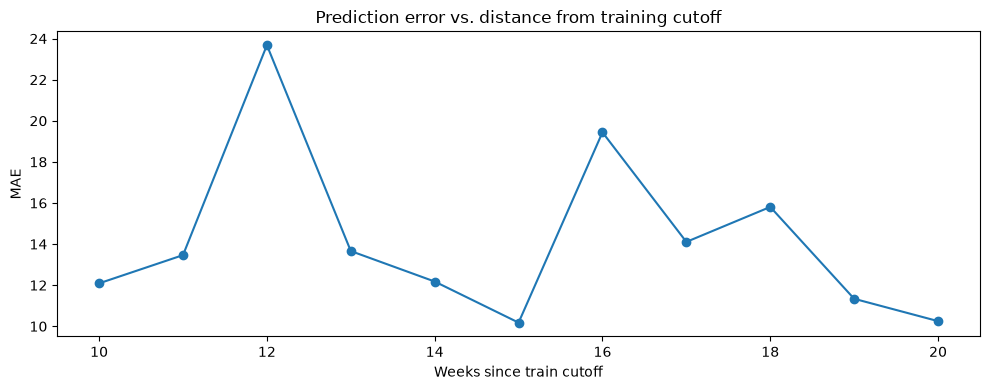

In [18]:
test_time = df['time'].iloc[val_end + GAP:].reset_index(drop=True)
weeks_since_cutoff = ((test_time - df['time'].iloc[train_end - 1]).dt.days // 7)

staleness_df = pd.DataFrame({
    "weeks_since_cutoff": weeks_since_cutoff.values,
    "y_true": y_test_24h.values,
    "y_pred": best_model_24h.predict(x_test_filtered),
})

bucket_scores = (
    staleness_df.groupby("weeks_since_cutoff")
    .apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
        "n_rows": len(g),
        "true_std": g["y_true"].std(),
    }))
    .reset_index()
)
print(bucket_scores.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bucket_scores["weeks_since_cutoff"], bucket_scores["MAE"], marker="o")
ax.set_xlabel("Weeks since train cutoff")
ax.set_ylabel("MAE")
ax.set_title("Prediction error vs. distance from training cutoff")
plt.tight_layout()
plt.savefig("staleness_check.png", dpi=150)
plt.show()


In [ ]:
def tune_horizon(x_train, y_train_h, x_test, y_test_h, label):
    search = RandomizedSearchCV(
        XGBRegressor(random_state=42),
        param_distributions=param_dist,  
        n_iter=40,
        scoring="neg_mean_absolute_error",
        cv=TimeSeriesSplit(n_splits=5, gap=72),
        random_state=42,
        n_jobs=-1,
    )
    search.fit(x_train, y_train_h)
    best = search.best_estimator_
    pred = best.predict(x_test)
    print(f"=== {label} ===")
    print("Best params:", search.best_params_)
    print("Best CV MAE:", -search.best_score_)
    print("Test MAE:", mean_absolute_error(y_test_h, pred))
    print("Test R2:", r2_score(y_test_h, pred))
    return best

best_model_48h = tune_horizon(x_train_filtered, y_train_48h, x_test_filtered, y_test_48h, "48h")
best_model_72h = tune_horizon(x_train_filtered, y_train_72h, x_test_filtered, y_test_72h, "72h")

=== 48h ===
Best params: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV MAE: 31.271820681964414
Test MAE: 18.77496782185342
Test R2: -0.07933769066944807
=== 72h ===
Best params: {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV MAE: 34.56040301682852
Test MAE: 18.182065584083304
Test R2: -0.014449508814910583


In [ ]:

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

def compare_boosters(x_train, y_train_h, x_test, y_test_h, baseline_result, label):
    results = [baseline_result]

    lgbm = LGBMRegressor(n_estimators=500, max_depth=4, learning_rate=0.03,
                          subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)
    lgbm.fit(x_train, y_train_h)
    results.append(evaluate(y_test_h, lgbm.predict(x_test), f"LightGBM ({label})"))

    cat = CatBoostRegressor(iterations=500, depth=4, learning_rate=0.03,
                             random_state=42, verbose=False)
    cat.fit(x_train, y_train_h)
    results.append(evaluate(y_test_h, cat.predict(x_test), f"CatBoost ({label})"))

    return pd.DataFrame(results).sort_values("MAE")

print(compare_boosters(x_train_filtered, y_train_24h, x_test_filtered, y_test_24h,
                        baseline_24h, "24h").to_string(index=False))
print(compare_boosters(x_train_filtered, y_train_48h, x_test_filtered, y_test_48h,
                        results_48h[0], "48h").to_string(index=False))
print(compare_boosters(x_train_filtered, y_train_72h, x_test_filtered, y_test_72h,
                        results_72h[0], "72h").to_string(index=False))

                 Model       MAE      RMSE     MAPE        R2
        CatBoost (24h) 14.146903 18.334680 0.094701  0.361156
        LightGBM (24h) 14.364330 18.560676 0.095999  0.345310
Baseline (Persistence) 17.308649 23.463052 0.121916 -0.046206
         Model       MAE      RMSE     MAPE        R2
CatBoost (48h) 20.191099 24.478962 0.135851 -0.154931
LightGBM (48h) 20.679719 25.603100 0.137253 -0.263442
Baseline (48h) 21.782583 29.309904 0.151676 -0.655766
         Model       MAE      RMSE     MAPE        R2
CatBoost (72h) 21.170867 25.433966 0.141016 -0.246444
Baseline (72h) 21.827014 30.187801 0.150632 -0.755932
LightGBM (72h) 23.619183 28.709767 0.157138 -0.588196


In [13]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)

if gpus:
    try:
        # Prevent TF from grabbing all VRAM upfront — avoids OOM crashes
        # on smaller laptop GPUs, and plays nicer if anything else needs the GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled — GPU ready.")
    except RuntimeError as e:
        # Must be set before any GPU op runs — if you see this, restart the kernel
        print("Config must happen before GPU is initialized:", e)
else:
    print("No GPU detected by TensorFlow. Common causes:")
    print("- CUDA/cuDNN version mismatch with your TF version")
    print("- Driver installed but tensorflow-gpu / correct TF build not installed")
    print("- Running inside a CPU-only virtualenv/container")

GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled — GPU ready.


In [14]:
# pip install tensorflow --break-system-packages
import numpy as np
import tensorflow as tf
from keras import layers, models

SEQ_LEN = 72  # look back 72 hours to predict ahead

def make_sequences(X, y, seq_len):
    """Turns tabular rows into (samples, timesteps, features) windows."""
    X_arr, y_arr = X.values, y.values
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i - seq_len:i])
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)

# Build sequences separately per split so the GAP-based leakage protection is preserved
# (sequences are never built across the train/test boundary)
X_train_seq, y_train_seq = make_sequences(x_train_filtered, y_train_24h, SEQ_LEN)
X_test_seq, y_test_seq = make_sequences(x_test_filtered, y_test_24h, SEQ_LEN)

# Scale features for the LSTM (unlike trees, neural nets need this)
from sklearn.preprocessing import StandardScaler
n_features = X_train_seq.shape[2]
seq_scaler = StandardScaler()
X_train_seq_scaled = seq_scaler.fit_transform(
    X_train_seq.reshape(-1, n_features)
).reshape(X_train_seq.shape)
X_test_seq_scaled = seq_scaler.transform(
    X_test_seq.reshape(-1, n_features)
).reshape(X_test_seq.shape)

# model = models.Sequential([
#     layers.Input(shape=(SEQ_LEN, n_features)),
#     layers.LSTM(64, return_sequences=True),
#     layers.Dropout(0.2),
#     layers.LSTM(32),
#     layers.Dropout(0.2),
#     layers.Dense(16, activation="relu"),
#     layers.Dense(1),
# ])
# model.compile(optimizer="adam", loss="mae")

# early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

# history = model.fit(
#     X_train_seq_scaled, y_train_seq,
#     validation_split=0.1,   # takes the last 10% of train chronologically — fine for early stopping
#     epochs=100,
#     batch_size=64,
#     callbacks=[early_stop],
#     verbose=1,
# )

# lstm_pred = model.predict(X_test_seq_scaled).flatten()
# print("=== LSTM (24h) ===")
# print("Test MAE:", mean_absolute_error(y_test_seq, lstm_pred))
# print("Test R2:", r2_score(y_test_seq, lstm_pred))
# print(f"\nCompare against XGBoost baseline: MAE={13.69:.2f}, R2={0.312:.2f}")

In [17]:
# Explicitly place the model build+fit on GPU, and print a confirmation
device_name = '/GPU:0' if gpus else '/CPU:0'
print(f"Training on: {device_name}")

with tf.device(device_name):
    model = models.Sequential([
        layers.Input(shape=(SEQ_LEN, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        # Output layer must stay float32 even under mixed precision —
        # keeps the final regression value numerically stable
        layers.Dense(1, dtype='float32'),
    ])
    model.compile(optimizer="adam", loss="mae")

    early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

    history = model.fit(
        X_train_seq_scaled, y_train_seq,
        validation_split=0.1,
        epochs=100,
        batch_size=128,     # see note below on tuning this
        callbacks=[early_stop],
        verbose=1,
    )

Training on: /GPU:0
Epoch 1/100
99/99 [==============================] - 5s 26ms/step - loss: 165.1736 - val_loss: 137.1407
Epoch 2/100
99/99 [==============================] - 2s 17ms/step - loss: 141.1868 - val_loss: 107.9413
Epoch 3/100
99/99 [==============================] - 2s 18ms/step - loss: 105.1369 - val_loss: 64.8020
Epoch 4/100
99/99 [==============================] - 2s 17ms/step - loss: 63.8481 - val_loss: 30.7687
Epoch 5/100
99/99 [==============================] - 2s 17ms/step - loss: 46.6589 - val_loss: 24.4279
Epoch 6/100
99/99 [==============================] - 2s 17ms/step - loss: 45.4879 - val_loss: 24.3238
Epoch 7/100
99/99 [==============================] - 2s 17ms/step - loss: 45.6206 - val_loss: 23.8784
Epoch 8/100
99/99 [==============================] - 2s 17ms/step - loss: 42.1966 - val_loss: 20.4634
Epoch 9/100
99/99 [==============================] - 2s 17ms/step - loss: 35.9837 - val_loss: 18.5814
Epoch 10/100
99/99 [==============================] - 2s 

In [18]:
lstm_test_pred = model.predict(X_test_seq_scaled).flatten()
print("LSTM Test MAE:", mean_absolute_error(y_test_seq, lstm_test_pred))
print("LSTM Test R2:", r2_score(y_test_seq, lstm_test_pred))
print(f"\nCompare: XGBoost Test MAE=13.69, R2=0.312")

51/51 [==============================] - 1s 13ms/step
LSTM Test MAE: 13.935343308023887
LSTM Test R2: 0.32353193971397265

Compare: XGBoost Test MAE=13.69, R2=0.312
